In [1]:
import pandas as panda
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = panda.read_csv("TSLA.csv", sep=",")

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-10-26,411.630005,425.760010,410.000000,420.279999,420.279999,28239200
1,2020-10-27,423.760010,430.500000,420.100006,424.679993,424.679993,22686500
2,2020-10-28,416.480011,418.600006,406.000000,406.019989,406.019989,25451400
3,2020-10-29,409.959991,418.059998,406.459991,410.829987,410.829987,22655300
4,2020-10-30,406.899994,407.589996,379.109985,388.040009,388.040009,42511300


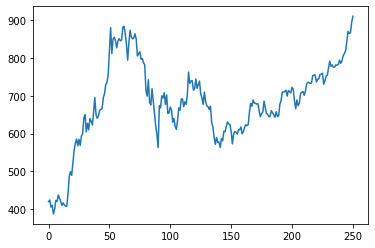

In [4]:
# Plot price over time
plt.plot(df["Close"])

In [5]:
# Convert Date data to ordinal date.
df["conv_date"] = panda.to_datetime(df["Date"])
df["conv_date"] = df["conv_date"].map(datetime.datetime.toordinal)
X = panda.DataFrame(df["conv_date"])
Y = panda.DataFrame(df["Close"])

In [6]:
# Split the data set in training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

In [7]:
linear_reg = LinearRegression()  # create object for the class
linear_reg.fit(X_train, y_train)  # perform linear regression
Y_pred = linear_reg.predict(X_train)  # make predictions

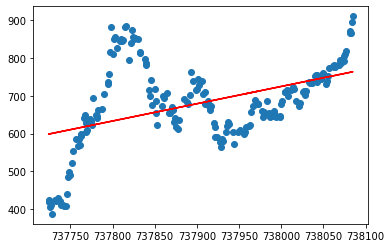

mse = 9974.155508301094


In [8]:
# Plot the results based on training data.
plt.scatter(X_train, y_train)
plt.plot(X_train, Y_pred, color='red')
plt.show()
print( "mse = " + str(metrics.mean_squared_error(y_train,Y_pred)))

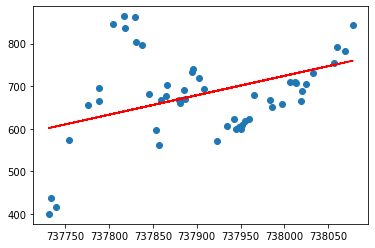

mse = 9229.393338886315


In [9]:
# Plot the results based on test data.
Y_pred = linear_reg.predict(X_test)
plt.scatter(X_test, y_test)
plt.plot(X_test, Y_pred, color='red')
plt.show()
print( "mse = " + str(metrics.mean_squared_error(y_test,Y_pred)))

In [10]:
# Converts input (str) date to numeric ordinal date. 
def priceAtDatePrediction(date):
    datetime = panda.to_datetime(date)
    date_as_ordinal = datetime.toordinal()
    prediction = linear_reg.predict([[date_as_ordinal]])
    return prediction

In [11]:
# Testing the model 
print(priceAtDatePrediction("2020-10-5"))

[[589.06144219]]


In [12]:
print("The linear regression model does not seem to be good for predicting stock prices. I think this is because stock prices is not linear.")

The linear regression model does not seem to be good for predicting stock prices. I think this is because stock prices is not linear.
